## Import thư viện và khởi tạo OCR Engine

In [1]:
import sys
sys.path.insert(0, '..')

import os
import json
import glob
import matplotlib.pyplot as plt
from PIL import Image

from src.ocr.ocr_processor import PaddleOCRProcessor

# Khởi tạo OCR processor
ocr_processor = PaddleOCRProcessor(
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False
)

c:\Users\Thach\miniconda3\envs\project\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.


Đang khởi tạo PaddleOCR engine...


c:\Users\Thach\miniconda3\envs\project\lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Thach\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Thach\.paddlex\official_models\PP-OCRv5_server_rec`.


-> PaddleOCR đã sẵn sàng!


## 1.5. Test Token Classification

Token classifier phân loại OCR tokens TRƯỚC khi grouping:
- **Form fields**: "Name:", "Date:", "Address:"
- **Dates**: "12/01/2024", "Jan 12, 2024"
- **Numbers**: "$1,234.56", "1000"
- **Codes**: "ABC12345", "INV-001"

In [2]:
from src.ocr.token_classifier import TokenClassifier

# Initialize classifier
classifier = TokenClassifier()

# Test với sample tokens
test_tokens = [
    {'text': 'Invoice Number:', 'bbox': [10, 10, 120, 30]},
    {'text': 'INV-2024-001', 'bbox': [130, 10, 220, 30]},
    {'text': 'Date:', 'bbox': [10, 40, 60, 60]},
    {'text': '12/01/2024', 'bbox': [70, 40, 150, 60]},
    {'text': 'Total Amount:', 'bbox': [10, 70, 110, 90]},
    {'text': '$1,234.56', 'bbox': [120, 70, 200, 90]},
]

# Classify
classified = classifier.classify_tokens(test_tokens)

print("="*70)
print("TOKEN CLASSIFICATION DEMO")
print("="*70)

for token in classified:
    print(f"{token['text']:20} → {token['token_type']}")

# Statistics
stats = classifier.get_statistics(classified)
print(f"\n{'Statistics':20} → {stats}")
print("="*70)

TOKEN CLASSIFICATION DEMO
Invoice Number:      → form_key
INV-2024-001         → text
Date:                → form_key
12/01/2024           → form_value
Total Amount:        → form_key
$1,234.56            → number

Statistics           → {'form_key': 3, 'text': 1, 'form_value': 1, 'number': 1}


## Cấu hình đường dẫn

In [3]:
from src.utils.constant import *
from src.ocr.layout import *

Input folder: d:\Thach\HUST\Project_1\VQA\code\dataset\DocVQA_Images
Output folder: d:\Thach\HUST\Project_1\VQA\code\dataset\DocVQA_OCR


## Chọn 1 ảnh mẫu

Chạy OCR với Layout Analysis...

KẾT QUẢ LAYOUT ANALYSIS
Số lines: 83
Số blocks: 40
Số regions: 4

Regions phát hiện:
--------------------------------------------------------------------------------

1. Type: TEXT | Score: 0.799
   - Avg line length: 93.9
   - Spacing uniformity: 0.66

2. Type: FIGURE | Score: 0.250
   - Empty center ratio: 0.50
   - Tick-like numbers: 0
   - Legend cluster: False

3. Type: FIGURE | Score: 0.425
   - Empty center ratio: 0.27
   - Tick-like numbers: 3
   - Legend cluster: True

4. Type: FORM | Score: 0.200
   - Colon ratio: 0.00
   - Left alignment: 1.00
   - Right alignment: 1.00


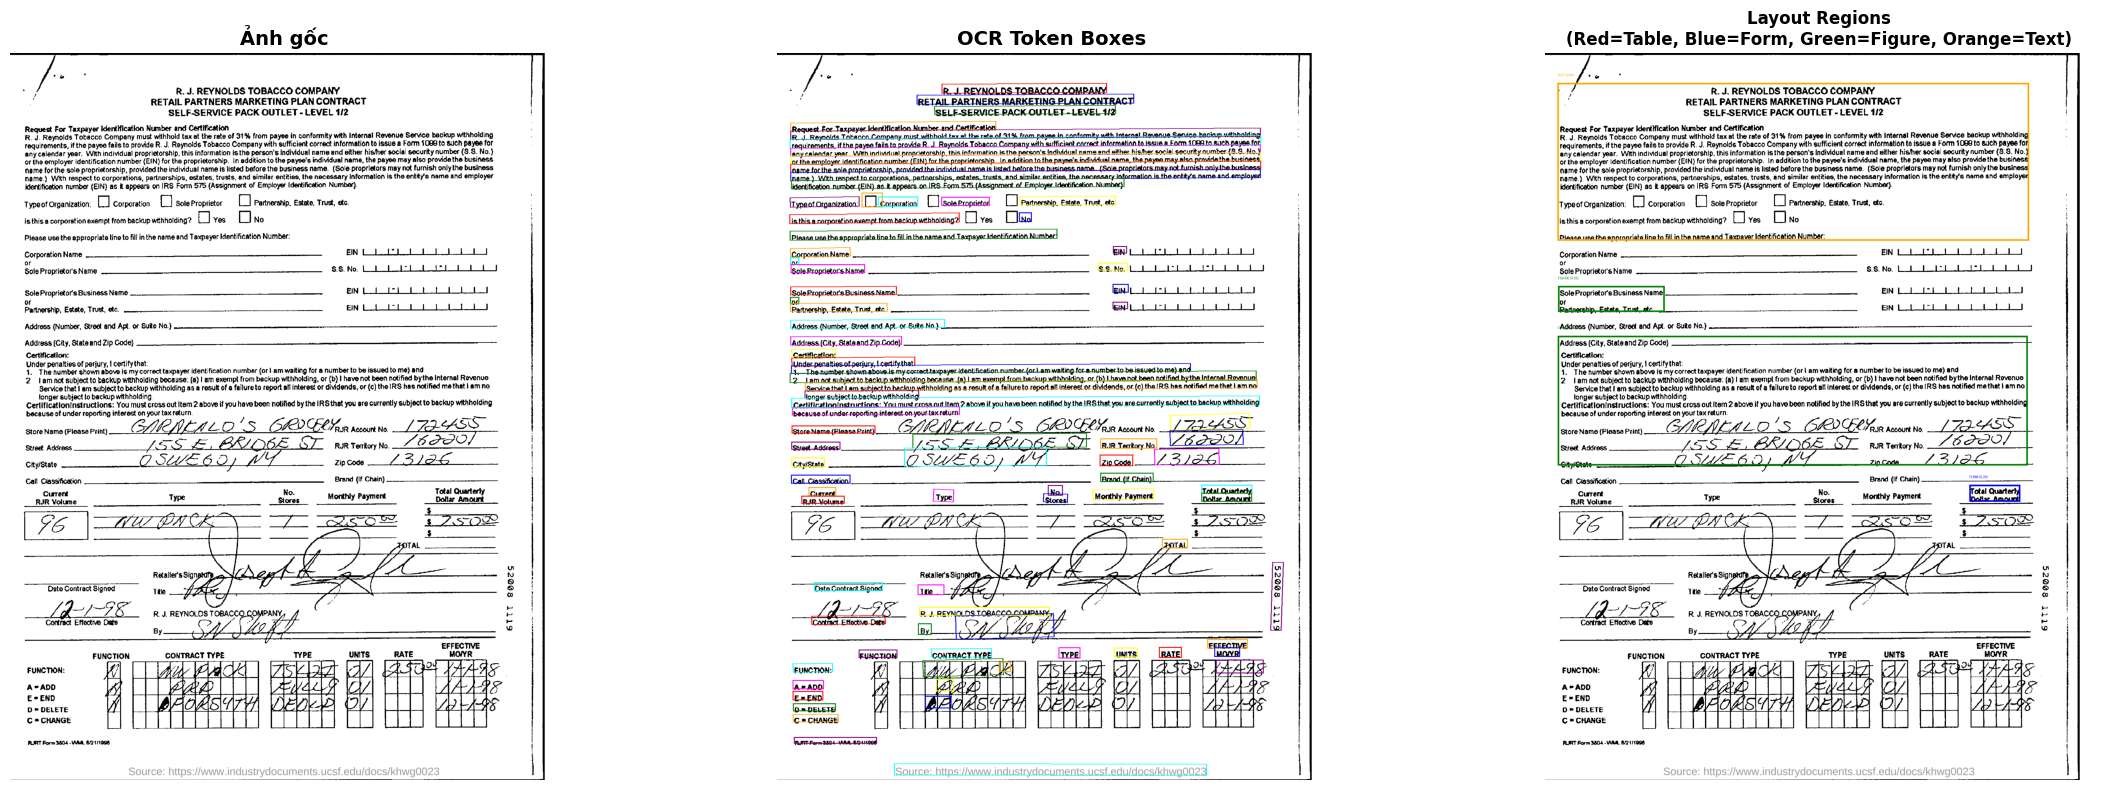


LEGEND - Region Colors:
  🔴 RED    = Table (bảng)
  🔵 BLUE   = Form (key:value)
  🟢 GREEN  = Figure (chart/plot)
  🟠 ORANGE = Text (đoạn văn)
  🟣 PURPLE = Layout (multi-column/heading)

TEXT CONTENT THEO TỪNG REGION

────────────────────────────────────────────────────────────────────────────────
📋 FORM REGIONS (1 phát hiện)
────────────────────────────────────────────────────────────────────────────────

[FORM #1] Score: 0.200
────────────────────────────────────────
 1. Total Quarterly
 2. Dollar Amount

────────────────────────────────────────────────────────────────────────────────
📋 FIGURE REGIONS (2 phát hiện)
────────────────────────────────────────────────────────────────────────────────

[FIGURE #1] Score: 0.250
────────────────────────────────────────
 1. Sole Proprietor'sBusiness Name
 2. or
 3. Partnership, Estate, Trust, etc.

[FIGURE #2] Score: 0.425
────────────────────────────────────────
 1. Address (City. Stateand Zip Code)
 2. Certificatlon:
 3. Under penalties of p

In [6]:
# Tìm 1 ảnh mẫu
import random

sample_image = '../dataset/DocVQA_Images\\train\\10668.png'
idx = random.randint(0, 1000)
if sample_image is None:
    for subset in SUBSETS:
        subset_folder = os.path.join(IMAGES_FOLDER, subset)
        if os.path.exists(subset_folder):
            images = glob.glob(os.path.join(subset_folder, "*.png"))[idx:idx+1]
            print(images)
            if images:
                sample_image = images[0]
                break
else:
    images = os.path.join(IMAGES_FOLDER, 'train', f'{sample_image}.png')
    
group(sample_image, ocr_processor)

---
## Document Layout Analysis

Phân tích cấu trúc document sau khi OCR:
- **Stage I**: Group token → line → block
- **Stage II**: Detect regions (table, form, figure, text, layout)

## Visualize Stage I Groups

Hiển thị các bước grouping ở Stage I:
- **Token**: Các bounding box từ OCR
- **Line**: Gộp tokens thành lines
- **Block**: Gộp lines thành blocks

Chạy OCR với Layout Analysis...


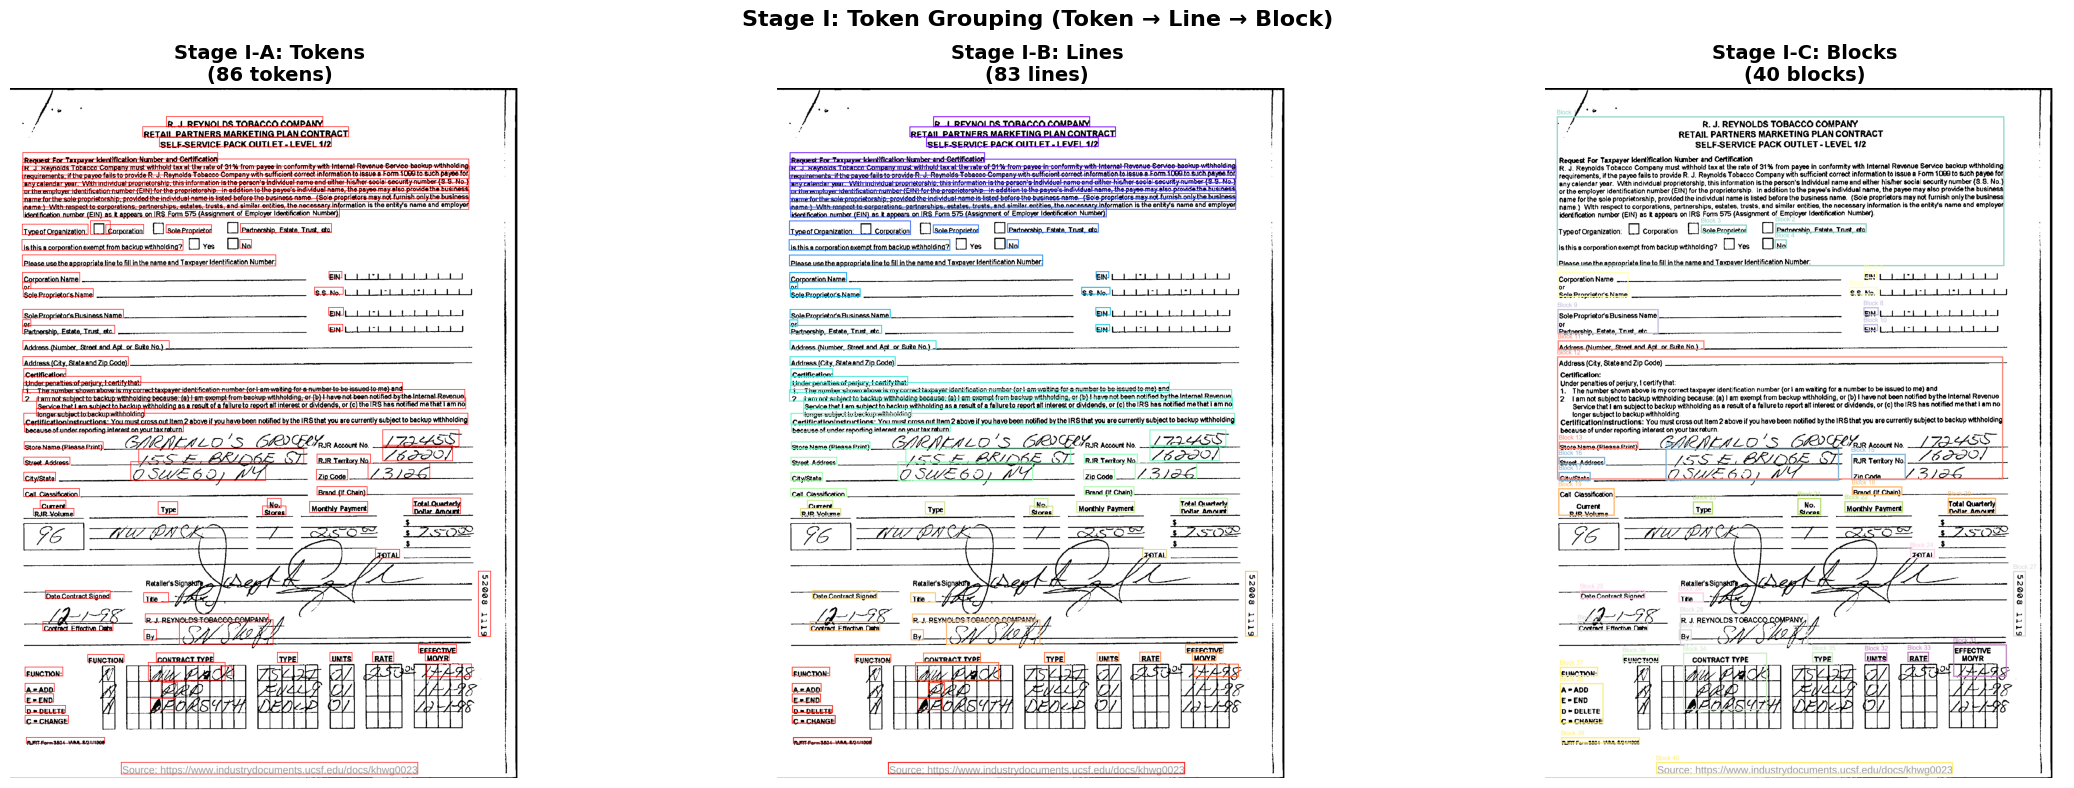


STAGE I - TOKEN GROUPING STATISTICS
Tokens: 86
Lines:  83
Blocks: 40



{'text': "R. J. REYNOLDS TOBACCO COMPANY RETAIL PARTNERS MARKETING PLAN CONTRACT SELF-SERVICE PACK OUTLET-LEVEL 1/2 Request For Taxpayer IdentHication Number and Certification R. j.Reynolds Tobacco Company must withhold tax at the rate of 31% from payee in conformity with Internal Revenue Service backup withholding requirements,if the payee fails to provide R.J.Reynolds Tobacco Company with sufficient correct information to issuea Form1g to such payee for anycalendar year. With individual proprietorshlp.this information isthe person's individual name and either hisher social security number (S.S.No.) or the employer identification number (EiN) for the proprietorship.In addition to the payee's individual name,the payee may also providethe business name for the sole proprietorship. provided the individual name is listed before the business name. (Sole proprletors may not furnish only the business name.) With respect to corporations, partnerships,estates, trusts,and similar entities, the 

In [7]:
visualize_stage1_groups(sample_image, ocr_processor)